<a href="https://colab.research.google.com/github/huanbv/BVU.CaoHoc.BuiVanHuan-XLA/blob/main/BVU_CaoHoc_BuiVanHuan_Seminar_Midtern_OpenCV_VisionMart_Example.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Co giãn tương phản tuyến tính từng khúc.
Mục đích: minh họa hàm biến đổi qua (r1, s1), (r2, s2), ảnh trước/sau co giãn và trường hợp phân ngưỡng.
Nguồn: theo Fig. 3.10 của giáo trình [1]. Cách tạo: Matplotlib vẽ hàm gấp khúc + OpenCV áp LUT tuyến tính từng khúc lên một ảnh xám tương phản thấp.

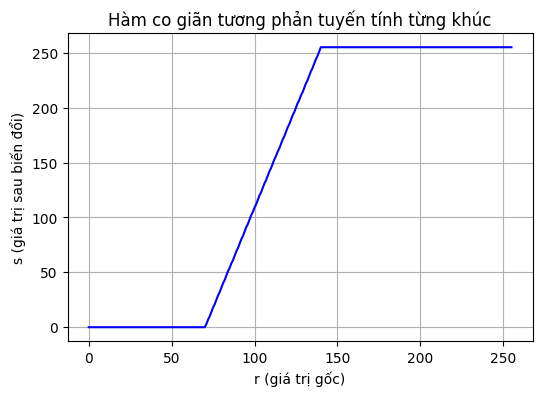

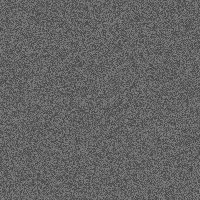

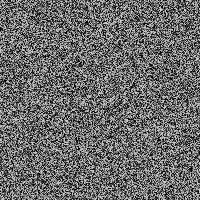

In [ ]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
from google.colab.patches import cv2_imshow

# --- Tạo ảnh giả lập tương phản thấp ---
# Ảnh 200x200 với mức xám quanh 100 ± 30
img = np.random.randint(70, 130, (200, 200), dtype=np.uint8)

# --- Tham số co giãn tuyến tính từng khúc ---
r1, s1 = 70, 0
r2, s2 = 140, 255
L = 256

# --- Tạo LUT ---
lut = np.zeros(L, dtype=np.uint8)
for r in range(L):
    if r < r1:
        lut[r] = int(s1 * r / r1)
    elif r1 <= r <= r2:
        lut[r] = int(s1 + (s2 - s1) * (r - r1) / (r2 - r1))
    else:
        lut[r] = int(s2 + (L-1 - s2) * (r - r2) / (L-1 - r2))

# --- Áp LUT lên ảnh ---
img_transformed = cv2.LUT(img, lut)

# --- Vẽ hàm biến đổi ---
plt.figure(figsize=(6,4))
plt.plot(range(L), lut, color='blue')
plt.title("Hàm co giãn tương phản tuyến tính từng khúc")
plt.xlabel("r (giá trị gốc)")
plt.ylabel("s (giá trị sau biến đổi)")
plt.grid(True)
plt.show()

# --- Hiển thị ảnh trước/sau trong Colab ---
cv2_imshow(img)
cv2_imshow(img_transformed)


Ảnh gốc (xám):


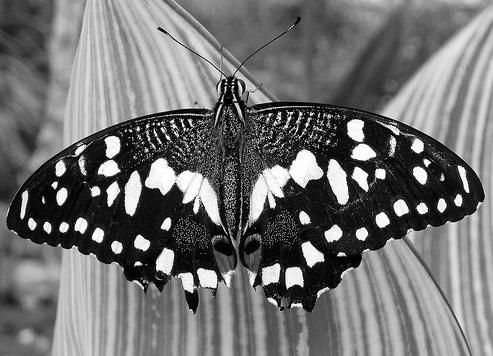

Ảnh cộng Laplacian:


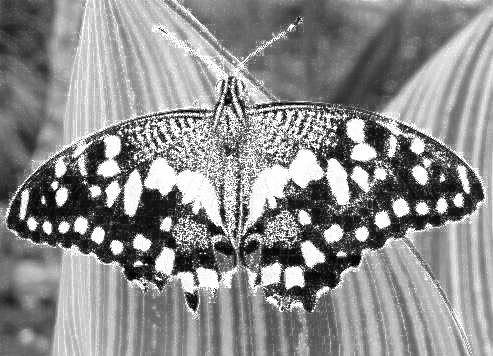

Unsharp masking (k=1):


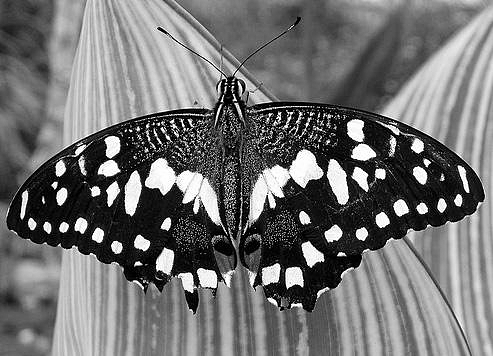

Highboost (k=2):


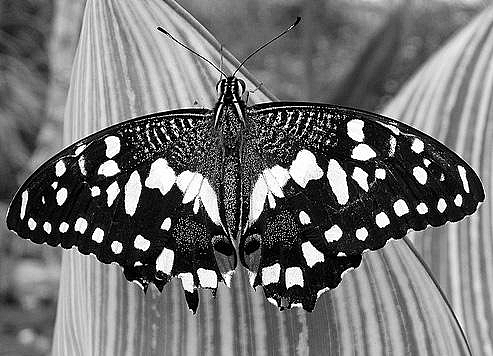

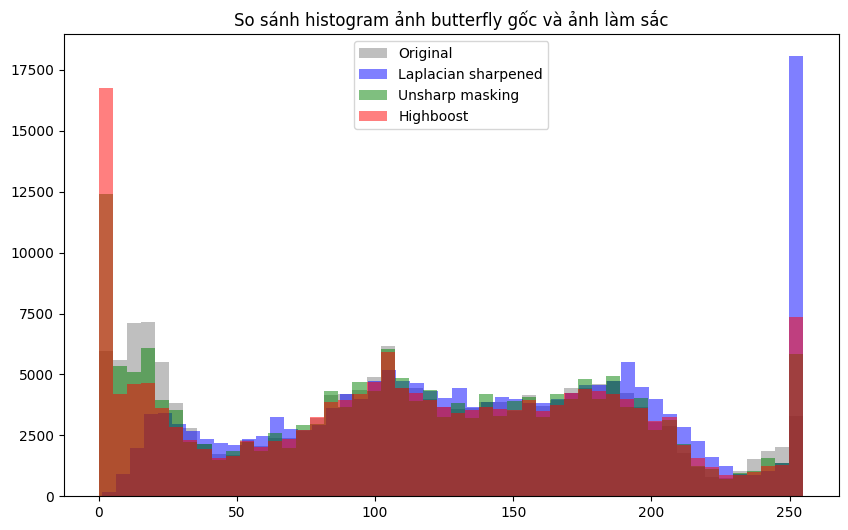

In [ ]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
from google.colab.patches import cv2_imshow
import urllib.request

# --- Tải ảnh butterfly từ URL ---
url = "https://raw.githubusercontent.com/opencv/opencv/master/samples/data/butterfly.jpg"
resp = urllib.request.urlopen(url)
image_array = np.asarray(bytearray(resp.read()), dtype=np.uint8)
img_color = cv2.imdecode(image_array, cv2.IMREAD_COLOR)

# Chuyển sang ảnh xám
img = cv2.cvtColor(img_color, cv2.COLOR_BGR2GRAY)

# --- Bộ lọc Laplacian với nhân tâm -4 ---
kernel_lap = np.array([[0, 1, 0],
                       [1,-4, 1],
                       [0, 1, 0]], dtype=np.float32)

laplacian = cv2.filter2D(img, cv2.CV_32F, kernel_lap)
laplacian = cv2.convertScaleAbs(laplacian)

# Ảnh cộng Laplacian (theo công thức 2.13)
img_lap = cv2.add(img, laplacian)

# --- Unsharp masking / Highboost ---
blur = cv2.GaussianBlur(img, (5,5), 1.0)

# Unsharp masking (k=1)
unsharp = cv2.addWeighted(img, 1.5, blur, -0.5, 0)

# Highboost (k=2)
highboost = cv2.addWeighted(img, 2.0, blur, -1.0, 0)

# --- Hiển thị kết quả ---
print("Ảnh gốc (xám):")
cv2_imshow(img)
print("Ảnh cộng Laplacian:")
cv2_imshow(img_lap)
print("Unsharp masking (k=1):")
cv2_imshow(unsharp)
print("Highboost (k=2):")
cv2_imshow(highboost)

# --- Vẽ histogram để so sánh ---
plt.figure(figsize=(10,6))
plt.hist(img.ravel(), bins=50, color='gray', alpha=0.5, label='Original')
plt.hist(img_lap.ravel(), bins=50, color='blue', alpha=0.5, label='Laplacian sharpened')
plt.hist(unsharp.ravel(), bins=50, color='green', alpha=0.5, label='Unsharp masking')
plt.hist(highboost.ravel(), bins=50, color='red', alpha=0.5, label='Highboost')
plt.legend()
plt.title("So sánh histogram ảnh butterfly gốc và ảnh làm sắc")
plt.show()


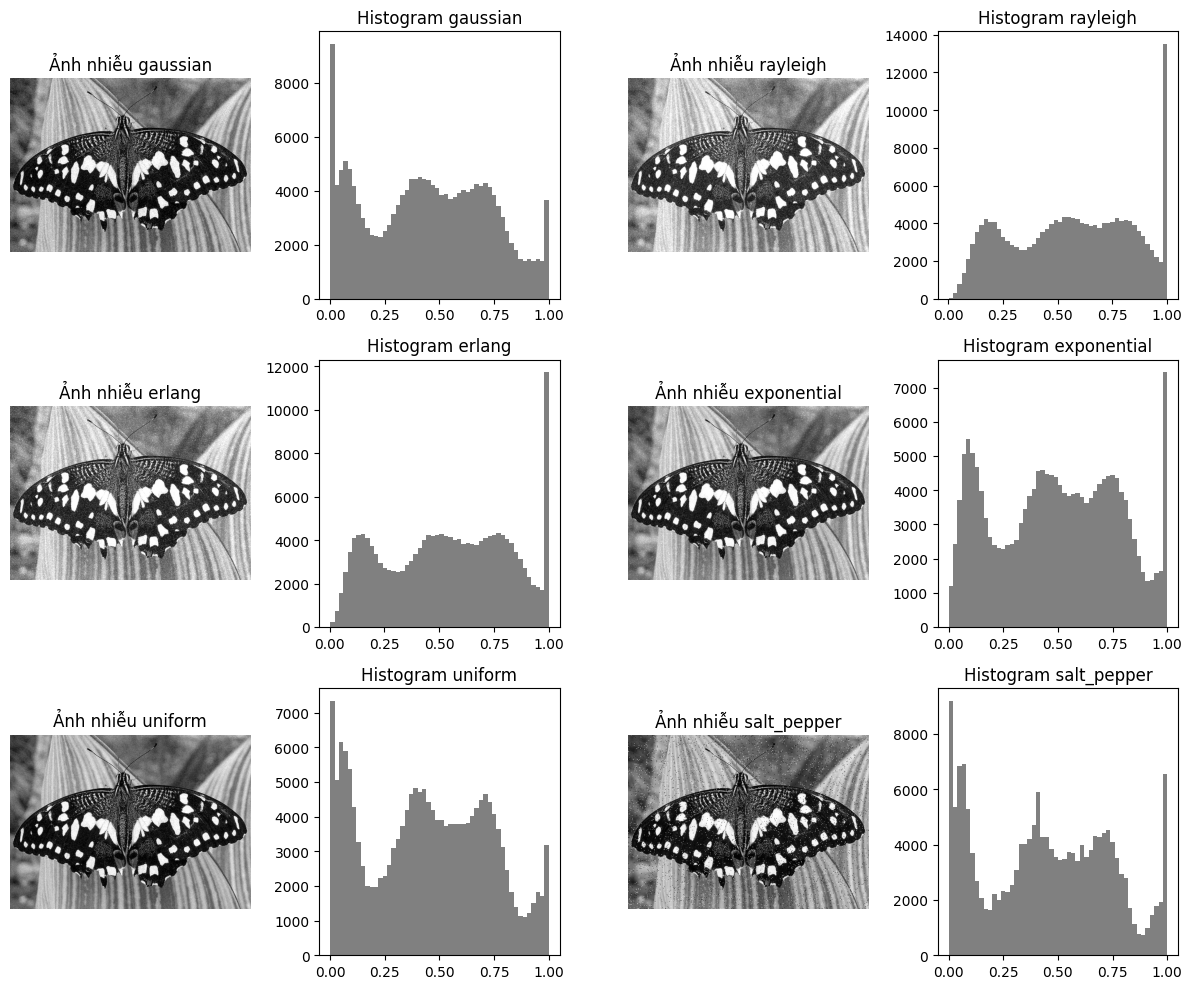

In [ ]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
from google.colab.patches import cv2_imshow
import urllib.request

# --- Đọc ảnh mẫu ---
url = "https://raw.githubusercontent.com/opencv/opencv/master/samples/data/butterfly.jpg"
resp = urllib.request.urlopen(url)
image_array = np.asarray(bytearray(resp.read()), dtype=np.uint8)
img_color = cv2.imdecode(image_array, cv2.IMREAD_COLOR)
img = cv2.cvtColor(img_color, cv2.COLOR_BGR2GRAY)
img = img.astype(np.float32) / 255.0  # chuẩn hóa [0,1]

# --- Hàm tạo nhiễu ---
def add_noise(img, noise_type):
    if noise_type == "gaussian":
        noise = np.random.normal(0, 0.05, img.shape)
        noisy = np.clip(img + noise, 0, 1)
    elif noise_type == "rayleigh":
        noise = np.random.rayleigh(0.1, img.shape)
        noisy = np.clip(img + noise, 0, 1)
    elif noise_type == "erlang":
        noise = np.random.gamma(shape=2.0, scale=0.05, size=img.shape)
        noisy = np.clip(img + noise, 0, 1)
    elif noise_type == "exponential":
        noise = np.random.exponential(0.05, img.shape)
        noisy = np.clip(img + noise, 0, 1)
    elif noise_type == "uniform":
        noise = np.random.uniform(-0.05, 0.05, img.shape)
        noisy = np.clip(img + noise, 0, 1)
    elif noise_type == "salt_pepper":
        noisy = img.copy()
        p_salt, p_pepper = 0.02, 0.02
        num_salt = int(np.ceil(p_salt * img.size))
        num_pepper = int(np.ceil(p_pepper * img.size))
        # Tạo tọa độ ngẫu nhiên cho salt
        coords_salt = (np.random.randint(0, img.shape[0], num_salt),
                       np.random.randint(0, img.shape[1], num_salt))
        noisy[coords_salt] = 1
        # Tạo tọa độ ngẫu nhiên cho pepper
        coords_pepper = (np.random.randint(0, img.shape[0], num_pepper),
                         np.random.randint(0, img.shape[1], num_pepper))
        noisy[coords_pepper] = 0
    else:
        noisy = img.copy()
    return noisy

# --- Danh sách nhiễu ---
noise_types = ["gaussian", "rayleigh", "erlang", "exponential", "uniform", "salt_pepper"]

plt.figure(figsize=(12, 10))
for i, ntype in enumerate(noise_types):
    noisy_img = add_noise(img, ntype)
    plt.subplot(3, 4, 2*i+1)
    plt.imshow(noisy_img, cmap='gray')
    plt.title(f"Ảnh nhiễu {ntype}")
    plt.axis('off')

    plt.subplot(3, 4, 2*i+2)
    plt.hist(noisy_img.ravel(), bins=50, color='gray')
    plt.title(f"Histogram {ntype}")

plt.tight_layout()
plt.show()


Ảnh nhiễu salt-pepper (P=0.25):


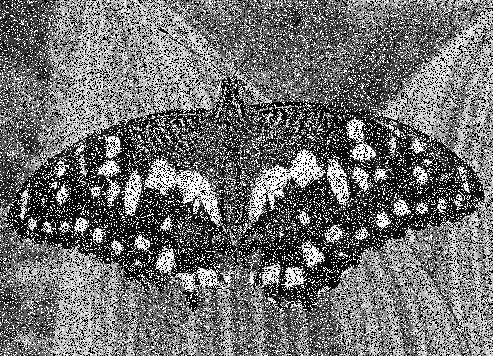

Trung bình cộng 7x7:


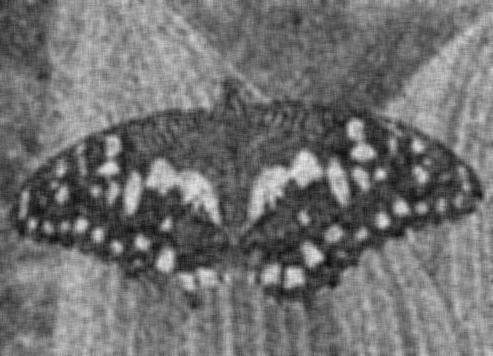

Trung vị 7x7:


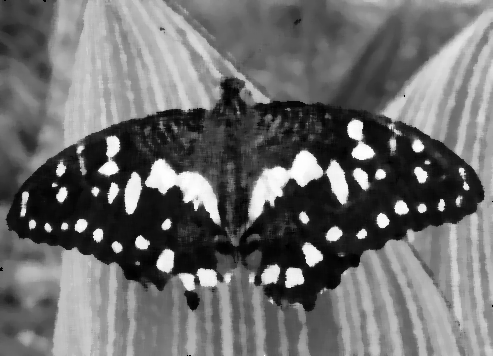

Trung vị thích nghi:


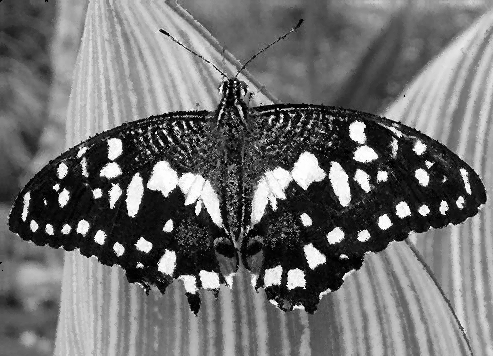

In [ ]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
from google.colab.patches import cv2_imshow

# --- Đọc ảnh mẫu ---
url = "https://raw.githubusercontent.com/opencv/opencv/master/samples/data/butterfly.jpg"
import urllib.request
resp = urllib.request.urlopen(url)
image_array = np.asarray(bytearray(resp.read()), dtype=np.uint8)
img_color = cv2.imdecode(image_array, cv2.IMREAD_COLOR)
img = cv2.cvtColor(img_color, cv2.COLOR_BGR2GRAY)

# --- Sinh nhiễu salt-pepper với P_s = P_p = 0.25 ---
noisy = img.copy()
p_salt, p_pepper = 0.25, 0.25
num_salt = int(np.ceil(p_salt * img.size))
num_pepper = int(np.ceil(p_pepper * img.size))
coords_salt = (np.random.randint(0, img.shape[0], num_salt),
               np.random.randint(0, img.shape[1], num_salt))
coords_pepper = (np.random.randint(0, img.shape[0], num_pepper),
                 np.random.randint(0, img.shape[1], num_pepper))
noisy[coords_salt] = 255
noisy[coords_pepper] = 0

# --- Trung bình cộng ---
mean_filtered = cv2.blur(noisy, (7,7))

# --- Trung vị 7x7 ---
median_filtered = cv2.medianBlur(noisy, 7)

# --- Adaptive median filter ---
def adaptive_median(img, max_size=7):
    padded = cv2.copyMakeBorder(img, max_size//2, max_size//2, max_size//2, max_size//2, cv2.BORDER_REFLECT)
    out = np.zeros_like(img)
    for i in range(img.shape[0]):
        for j in range(img.shape[1]):
            size = 3
            while size <= max_size:
                region = padded[i:i+size, j:j+size].flatten()
                z_min, z_max, z_med = np.min(region), np.max(region), np.median(region)
                z_xy = padded[i+size//2, j+size//2]
                if z_med > z_min and z_med < z_max:
                    if z_xy > z_min and z_xy < z_max:
                        out[i,j] = z_xy
                    else:
                        out[i,j] = z_med
                    break
                else:
                    size += 2
            if size > max_size:
                out[i,j] = z_med
    return out.astype(np.uint8)

adaptive_filtered = adaptive_median(noisy, max_size=7)

# --- Hiển thị kết quả ---
print("Ảnh nhiễu salt-pepper (P=0.25):")
cv2_imshow(noisy)
print("Trung bình cộng 7x7:")
cv2_imshow(mean_filtered)
print("Trung vị 7x7:")
cv2_imshow(median_filtered)
print("Trung vị thích nghi:")
cv2_imshow(adaptive_filtered)


Ảnh gốc:


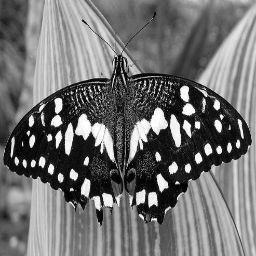

Ảnh mờ + nhiễu:


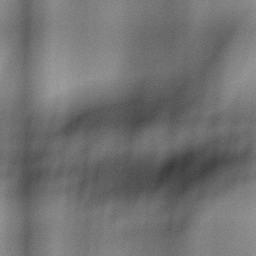

Phục hồi bằng lọc ngược:


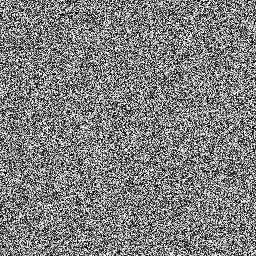

Phục hồi bằng lọc Wiener:


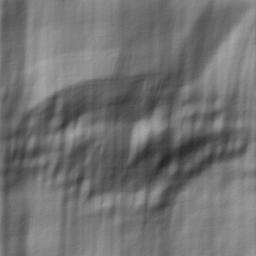

In [ ]:
import cv2, numpy as np, matplotlib.pyplot as plt
from google.colab.patches import cv2_imshow

# --- Đọc ảnh mẫu ---
url = "https://raw.githubusercontent.com/opencv/opencv/master/samples/data/butterfly.jpg"
import urllib.request
resp = urllib.request.urlopen(url)
image_array = np.asarray(bytearray(resp.read()), dtype=np.uint8)
img_color = cv2.imdecode(image_array, cv2.IMREAD_COLOR)
img = cv2.cvtColor(img_color, cv2.COLOR_BGR2GRAY)
img = cv2.resize(img, (256,256))  # giảm kích thước cho nhanh
f = img.astype(np.float32)/255.0

# --- Tạo hàm truyền H(u,v) cho motion blur ---
M,N = f.shape
u = np.arange(M); v = np.arange(N)
U,V = np.meshgrid(u,v,indexing='ij')
a,b,T = 0.1,0.1,1
pi = np.pi
H = np.sinc(a*U + b*V) * np.exp(-1j*pi*(a*U+b*V))

# --- Biến đổi Fourier ảnh ---
F = np.fft.fft2(f)
G = F*H

# --- Cộng nhiễu Gaussian ---
noise = np.random.normal(0,0.01,f.shape)
G_noisy = G + np.fft.fft2(noise)

# --- Lọc ngược ---
F_inv = G_noisy / (H + 1e-8)
f_inv = np.abs(np.fft.ifft2(F_inv))

# --- Lọc Wiener ---
K = 0.01
H_conj = np.conj(H)
F_wiener = (H_conj/(np.abs(H)**2 + K)) * G_noisy
f_wiener = np.abs(np.fft.ifft2(F_wiener))

# --- Hiển thị kết quả ---
print("Ảnh gốc:")
cv2_imshow((f*255).astype(np.uint8))
print("Ảnh mờ + nhiễu:")
cv2_imshow(np.abs(np.fft.ifft2(G_noisy))*255)
print("Phục hồi bằng lọc ngược:")
cv2_imshow((f_inv*255).astype(np.uint8))
print("Phục hồi bằng lọc Wiener:")
cv2_imshow((f_wiener*255).astype(np.uint8))


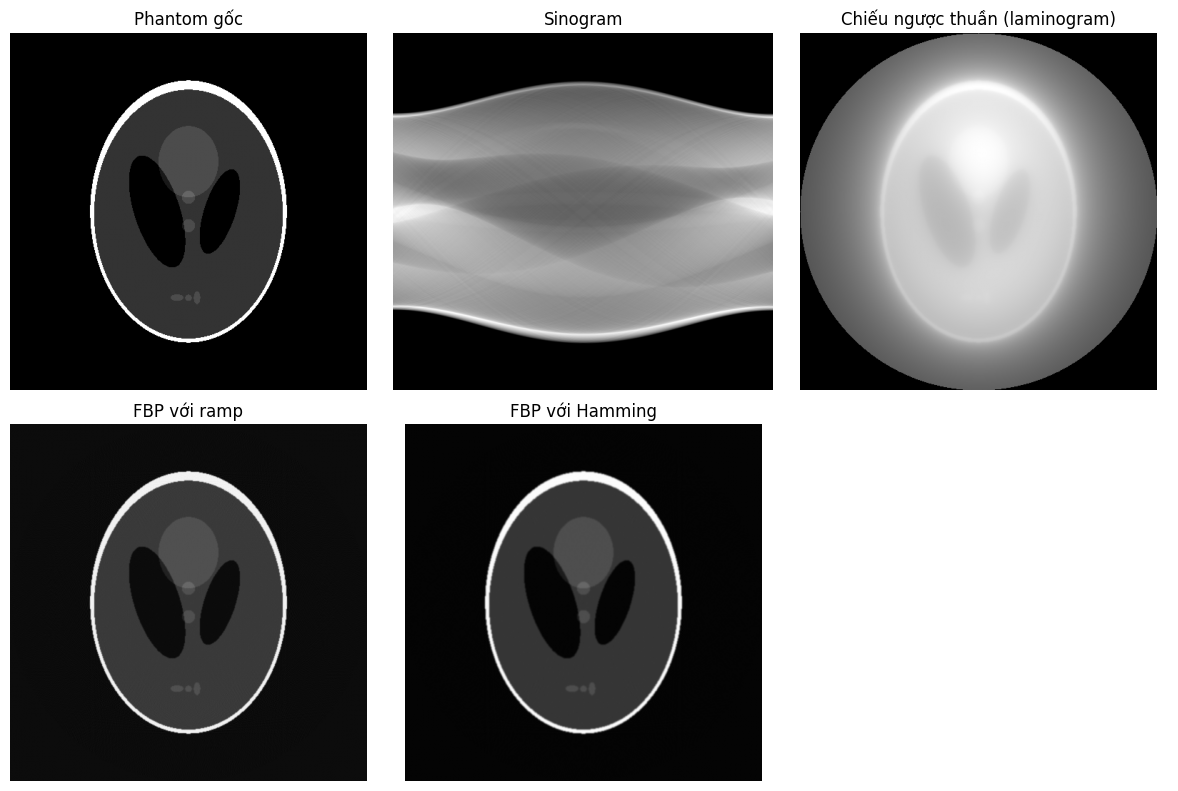

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from skimage.data import shepp_logan_phantom
from skimage.transform import radon, iradon
from skimage import img_as_float

# --- Tạo phantom Shepp-Logan ---
phantom = img_as_float(shepp_logan_phantom())
phantom = np.pad(phantom, ((50,50),(50,50)), mode='constant')  # pad cho dễ nhìn

# --- Tính sinogram ---
theta = np.linspace(0., 180., max(phantom.shape), endpoint=False)
sinogram = radon(phantom, theta=theta)

# --- Tái tạo bằng chiếu ngược ---
reconstruction_bp = iradon(sinogram, theta=theta, filter_name=None)  # backprojection thuần
reconstruction_ramp = iradon(sinogram, theta=theta, filter_name="ramp")  # FBP với ramp
reconstruction_hamming = iradon(sinogram, theta=theta, filter_name="hamming")  # FBP với Hamming

# --- Hiển thị kết quả ---
fig, axes = plt.subplots(2, 3, figsize=(12,8))
axes[0,0].set_title("Phantom gốc")
axes[0,0].imshow(phantom, cmap='gray')
axes[0,0].axis('off')

axes[0,1].set_title("Sinogram")
axes[0,1].imshow(sinogram, cmap='gray', aspect='auto')
axes[0,1].axis('off')

axes[0,2].set_title("Chiếu ngược thuần (laminogram)")
axes[0,2].imshow(reconstruction_bp, cmap='gray')
axes[0,2].axis('off')

axes[1,0].set_title("FBP với ramp")
axes[1,0].imshow(reconstruction_ramp, cmap='gray')
axes[1,0].axis('off')

axes[1,1].set_title("FBP với Hamming")
axes[1,1].imshow(reconstruction_hamming, cmap='gray')
axes[1,1].axis('off')

axes[1,2].axis('off')  # để trống

plt.tight_layout()
plt.show()
